<div style = "background-color:#1F3864; padding:25px; border-radius:8px;">
<h1 style="color:white; text-align:center; margin:0;"> Will AI Take My Job? — Exposure, Skills & Wages</h1>
<p style="color:#D9E2F3; text-align:center; margin-top:10px; font-size:15px;">
Analyzing which U.S. occupations are most exposed to AI -
combining BLS wage data, O*NET cognitive skill profiles, and published AI-exposure research (GPTs are GPTs, Felten AIOE)
</p>
</div>

## Overview

This notebook explores 271 U.S. occupations to understand which kinds of work — and which underlying human skills — are most and least exposed to AI. Rather than relying on speculation, every value here comes from a named primary source: no synthetic or fabricated data.

**Key questions this notebook explores:**
- Does AI exposure rise or fall with education level?
- Which cognitive skills (verbal, quantitative, spatial, reasoning) are most associated with high AI exposure?
- How does AI exposure relate to wages — are the most exposed jobs also the highest-paid?
- Which occupations sit at each extreme of the exposure spectrum?

## Data Sources

| Source | What it provides |
|---|---|
| **U.S. Bureau of Labor Statistics (BLS)** | Median wage, employment counts, 10-year growth projections, required education (May 2024 data, 2024–2034 projections) |
| **O\*NET** | Cognitive ability profiles per occupation — verbal, reasoning, quantitative, memory, perceptual, spatial, attention |
| **Eloundou et al., "GPTs are GPTs"** | Share of occupational tasks exposed to large language models |
| **Felten AIOE** | Broader AI-occupational-exposure index |

## Repository

Full production pipeline (config, feature engineering, training, FastAPI serving, Docker deployment) available on GitHub:
**[github.com/abdallahh07/ai-job-exposure-analysis](https://github.com/abdallahh07/ai-job-exposure-analysis)**

This notebook covers the research/EDA phase. The linked repo contains the production-ready version.

In [103]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">1. Load the Data</h2>
</div>

In [104]:
ai_exposure = pd.read_csv("data/ai_job_exposure.csv")
cognitive_ability = pd.read_csv("data/cognitive_ability_ai_exposure.csv")
occupation_cognitive = pd.read_csv("data/occupation_cognitive_profile.csv")

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">2. Review Data Structure</h2>
</div>

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">2.1 Checking the data types</h3>
</div>

In [105]:
ai_exposure.dtypes

occupation_title                   object
soc_code                           object
job_category                       object
education_required                 object
median_annual_wage_usd            float64
employment_2024                   float64
projected_growth_pct_2024_2034    float64
growth_outlook                     object
ai_exposure_llm_human             float64
ai_exposure_llm_gpt4              float64
ai_exposure_aioe                  float64
ai_exposure_level                  object
top_cognitive_ability              object
top_cognitive_family               object
distinctive_cognitive_strength     object
cognitive_demand_score            float64
verbal_ability                    float64
reasoning_ability                 float64
quantitative_ability              float64
memory_ability                    float64
perceptual_ability                float64
spatial_ability                   float64
attention_ability                 float64
dtype: object

In [106]:
cognitive_ability.dtypes

cognitive_ability     object
cognitive_family      object
ai_exposure_score    float64
dtype: object

In [107]:
occupation_cognitive.dtypes

soc_code                   object
occupation_title           object
Oral Comprehension        float64
Written Comprehension     float64
Oral Expression           float64
Written Expression        float64
Fluency of Ideas          float64
Originality               float64
Problem Sensitivity       float64
Deductive Reasoning       float64
Inductive Reasoning       float64
Information Ordering      float64
Category Flexibility      float64
Mathematical Reasoning    float64
Number Facility           float64
Memorization              float64
Speed of Closure          float64
Flexibility of Closure    float64
Perceptual Speed          float64
Spatial Orientation       float64
Visualization             float64
Selective Attention       float64
Time Sharing              float64
dtype: object

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">2.2 Checking the data distrubtion</h3>
</div>

In [108]:
ai_exposure.describe()

,median_annual_wage_usd,employment_2024,projected_growth_pct_2024_2034,ai_exposure_llm_human,ai_exposure_llm_gpt4,ai_exposure_aioe,cognitive_demand_score,verbal_ability,reasoning_ability,quantitative_ability,memory_ability,perceptual_ability,spatial_ability,attention_ability
count,271.000000,2.710000e+02,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000
mean,76142.745387,3.009590e+05,4.217712,0.350982,0.379225,0.368616,3.080561,3.720926,3.373945,2.697387,2.488970,2.777030,2.113542,2.873989
std,31629.210972,5.235404e+05,6.700513,0.190413,0.186295,0.895120,0.262887,0.399894,0.331671,0.578721,0.335437,0.315775,0.433504,0.224438
min,31190.000000,1.500000e+03,-14.000000,0.000000,0.000000,-2.123000,2.103000,2.530000,2.343000,1.060000,1.500000,1.377000,1.250000,2.190000
25%,52000.000000,3.880000e+04,1.000000,0.192000,0.250000,-0.246000,2.933000,3.508500,3.179500,2.224000,2.250000,2.623000,1.800000,2.750000
50%,66490.000000,1.052000e+05,4.000000,0.368000,0.412000,0.547000,3.124000,3.843000,3.427000,2.750000,2.500000,2.793000,2.050000,2.894000
75%,93955.000000,3.386500e+05,6.000000,0.491000,0.510000,1.145500,3.268000,4.000000,3.625000,3.051500,2.750000,2.960000,2.439000,3.000000
max,198100.000000,3.391000e+06,50.000000,0.844000,0.958000,1.528000,3.810000,4.500000,3.981000,4.500000,3.880000,4.207000,3.468000,4.310000


In [109]:
cognitive_ability.describe()

,ai_exposure_score
count,21.000000
mean,0.833667
std,0.507950
min,-0.144000
25%,0.483000
50%,0.670000
75%,1.240000
max,1.908000


In [110]:
occupation_cognitive.describe()

,Oral Comprehension,Written Comprehension,Oral Expression,Written Expression,Fluency of Ideas,Originality,Problem Sensitivity,Deductive Reasoning,Inductive Reasoning,Information Ordering,...,Mathematical Reasoning,Number Facility,Memorization,Speed of Closure,Flexibility of Closure,Perceptual Speed,Spatial Orientation,Visualization,Selective Attention,Time Sharing
count,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,...,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000
mean,3.862989,3.702288,3.831845,3.486531,3.072362,3.008967,3.699852,3.627528,3.555387,3.439742,...,2.735830,2.658930,2.488930,2.562251,2.959815,2.809004,1.430185,2.796974,3.066827,2.681255
std,0.327855,0.479262,0.371434,0.535255,0.457928,0.484940,0.364168,0.390504,0.427506,0.323504,...,0.617416,0.553734,0.335447,0.343595,0.353766,0.357141,0.522243,0.506450,0.224399,0.289512
min,2.880000,2.120000,2.750000,2.000000,2.000000,1.880000,2.380000,2.250000,2.380000,2.130000,...,1.000000,1.120000,1.500000,1.130000,1.750000,1.250000,1.000000,1.500000,2.500000,1.880000
25%,3.750000,3.380000,3.690000,3.120000,2.880000,2.750000,3.500000,3.380000,3.170000,3.185000,...,2.250000,2.145000,2.250000,2.250000,2.750000,2.620000,1.000000,2.380000,3.000000,2.500000
50%,4.000000,3.880000,3.960000,3.620000,3.000000,3.000000,3.780000,3.750000,3.620000,3.440000,...,2.750000,2.730000,2.500000,2.600000,3.000000,2.880000,1.210000,2.880000,3.000000,2.750000
75%,4.000000,4.000000,4.000000,3.880000,3.380000,3.285000,4.000000,4.000000,3.925000,3.730000,...,3.100000,3.000000,2.750000,2.750000,3.120000,3.000000,1.750000,3.120000,3.130000,2.880000
max,4.620000,4.880000,4.880000,4.620000,4.120000,4.120000,4.750000,4.380000,4.250000,4.000000,...,4.750000,4.250000,3.880000,4.250000,4.250000,4.120000,3.880000,4.250000,4.500000,4.120000


## Initial Analysis

**Outliers**: No significant outliers detected across the numeric columns (wage, employment counts, cognitive ability scores, exposure indices). Values fall within expected, plausible ranges for U.S. occupational data.

In [111]:
ai_exposure.shape,cognitive_ability.shape,occupation_cognitive.shape

((271, 23), (21, 3), (271, 23))

## Dataset Size & Shape

| File | Rows | Columns |
|---|---|---|
| `ai_job_exposure.csv` | 271 | 23 |
| `cognitive_ability_ai_exposure.csv` | 21 | 3 |
| `occupation_cognitive_profile.csv` | 271 | 23 |

**Note**: `ai_job_exposure.csv` and `occupation_cognitive_profile.csv` share the same shape (271 rows, 23 columns) — worth checking whether their columns overlap before merging, to confirm they contribute distinct information rather than duplicated data.

**Generalization concern**: with only 271 occupation-level rows, this is a small dataset relative to typical ML use cases. This has direct implications for modeling choices later — simpler models (e.g. Linear Regression) are likely to generalize better than high-capacity models, a generous test split and/or cross-validation will be more reliable than a single train/test split, and any reported performance metrics should be interpreted with appropriate caution given the limited sample size.

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">2.3 Checking for missing values</h3>
</div>

In [112]:
ai_exposure.isna().sum()

occupation_title                  0
soc_code                          0
job_category                      0
education_required                0
median_annual_wage_usd            0
employment_2024                   0
projected_growth_pct_2024_2034    0
growth_outlook                    0
ai_exposure_llm_human             0
ai_exposure_llm_gpt4              0
ai_exposure_aioe                  0
ai_exposure_level                 0
top_cognitive_ability             0
top_cognitive_family              0
distinctive_cognitive_strength    0
cognitive_demand_score            0
verbal_ability                    0
reasoning_ability                 0
quantitative_ability              0
memory_ability                    0
perceptual_ability                0
spatial_ability                   0
attention_ability                 0
dtype: int64

In [113]:
cognitive_ability.isna().sum()

cognitive_ability    0
cognitive_family     0
ai_exposure_score    0
dtype: int64

In [114]:
occupation_cognitive.isna().sum()

soc_code                  0
occupation_title          0
Oral Comprehension        0
Written Comprehension     0
Oral Expression           0
Written Expression        0
Fluency of Ideas          0
Originality               0
Problem Sensitivity       0
Deductive Reasoning       0
Inductive Reasoning       0
Information Ordering      0
Category Flexibility      0
Mathematical Reasoning    0
Number Facility           0
Memorization              0
Speed of Closure          0
Flexibility of Closure    0
Perceptual Speed          0
Spatial Orientation       0
Visualization             0
Selective Attention       0
Time Sharing              0
dtype: int64

## Missing Values

No missing values detected across any of the three files. This is expected given the dataset's small size (271 occupations) — with a compact, curated dataset like this, the creator likely filtered out or excluded occupations with incomplete records during compilation, rather than leaving gaps for downstream handling. Worth keeping in mind going forward: a dataset this size having zero missing values is more a sign of upstream curation than a guarantee that every occupation in the real O*NET/BLS universe would be equally clean.

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">3. Explanatory Data Analysis (EDA)</h2>
</div>

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">3.1 Statistical Analysis</h3>
</div>

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">3.1.1 ai_exposure</h3>
</div>

In [115]:
import os
os.makedirs("charts",exist_ok=True)

In [116]:
ai = ai_exposure.select_dtypes(include = "number").columns.tolist()

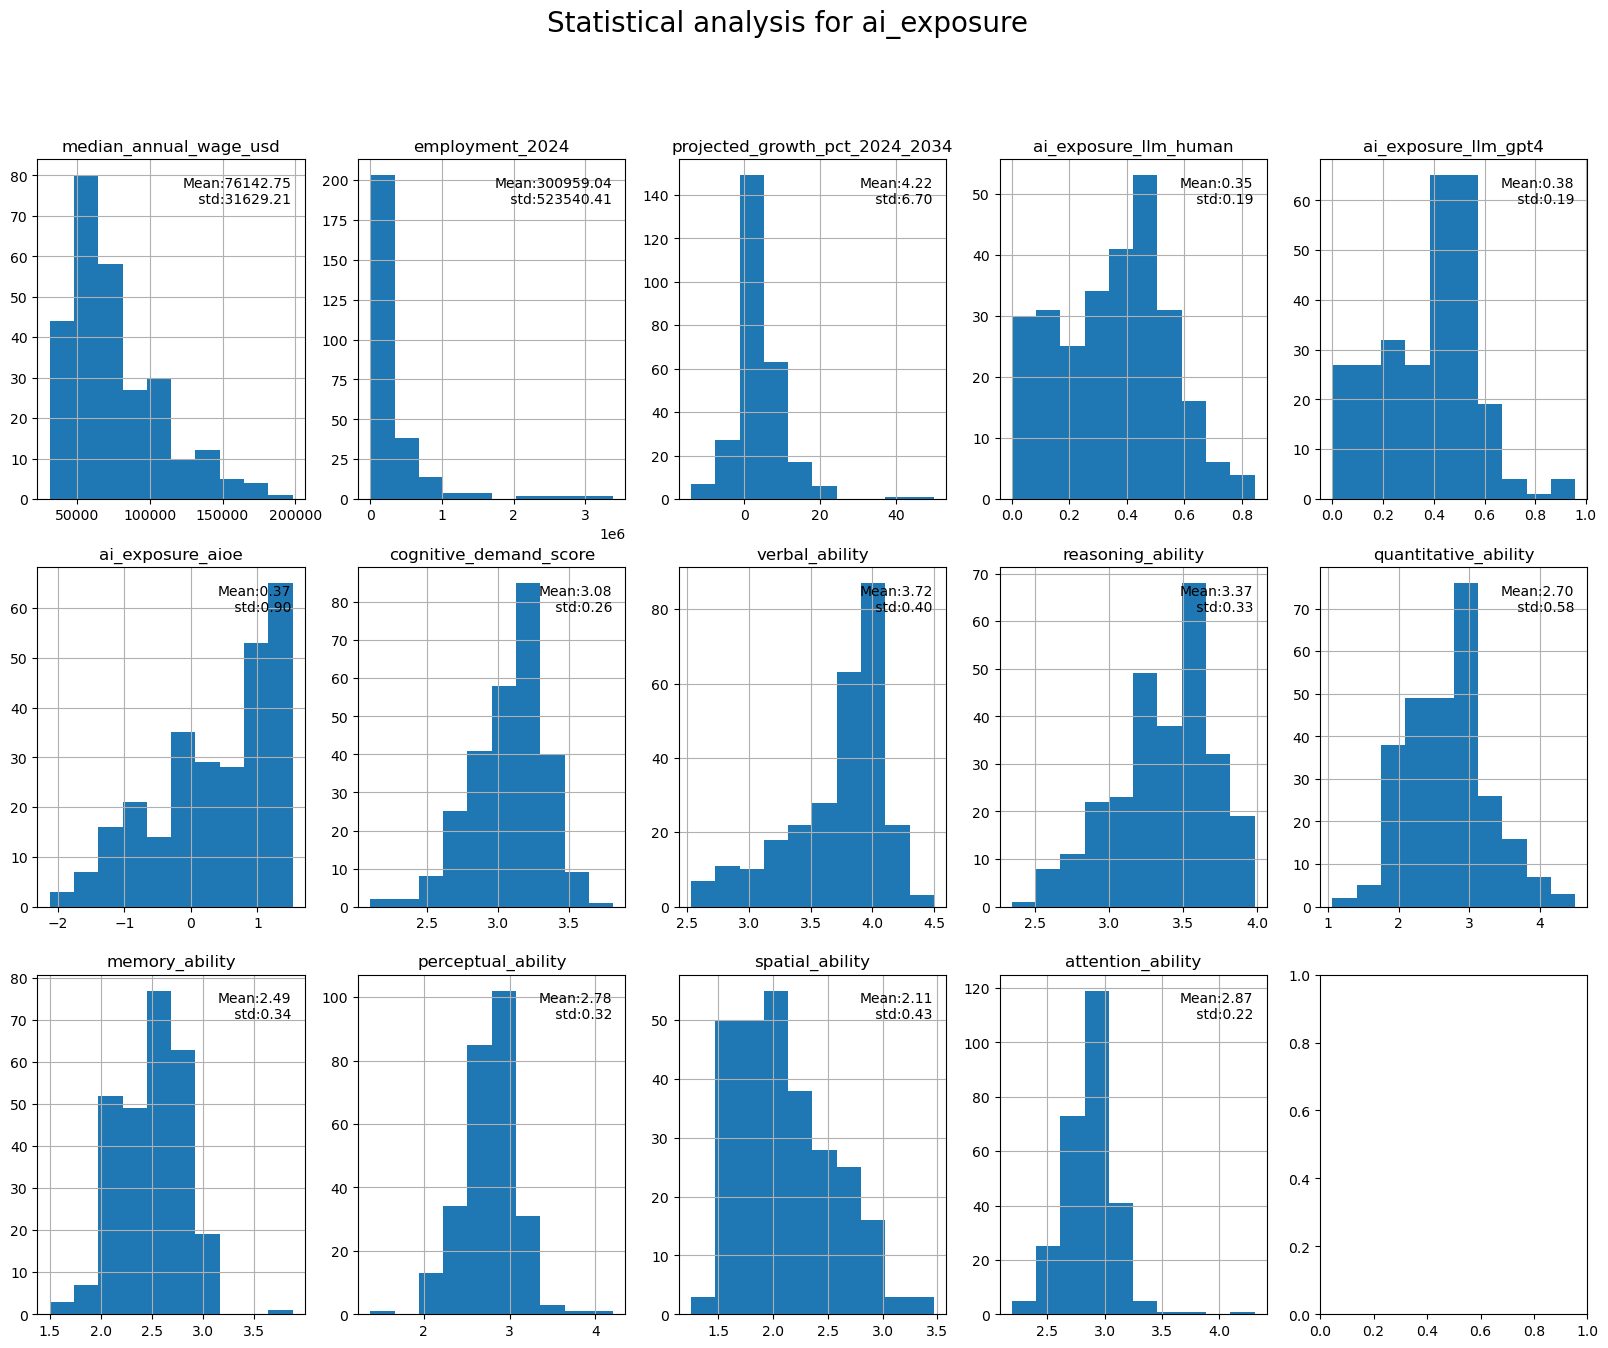

In [117]:
fig,ax = plt.subplots(3,5,figsize=(20,15))
plt.suptitle("Statistical analysis for ai_exposure",fontsize=20)
ax = ax.flatten()
for i , name in enumerate(ai):
    ai_exposure[name].hist(ax=ax[i])
    mean = ai_exposure[name].mean()
    std = ai_exposure[name].std()
    ax[i].text(0.95,0.95,f"Mean:{mean:.2f}\n std:{std:.2f}",
               ha = "right",va="top",transform=ax[i].transAxes)
    ax[i].set_title(name)
plt.tight_layout
plt.savefig("charts/statistical_analysis_ai_exposure.png")
plt.show()

## 3.1 Statistical Analysis

**AI Exposure & Labor Market Data** (`ai_job_exposure.csv`)

- `median_annual_wage_usd` and `employment_2024` are both strongly right-skewed — most occupations cluster at lower wage/employment levels, with a long tail of high-wage or high-employment outliers. Typical of labor market data.
- The three AI exposure measures (`ai_exposure_llm_human`, `ai_exposure_llm_gpt4`, `ai_exposure_aioe`) show broadly similar central tendencies (means 0.35–0.38 for the LLM-based scores), suggesting reasonable agreement between methodologies — worth confirming with a direct correlation check.
- `ai_exposure_aioe` shows a mean of 0.37 and std of 0.90 in this subset — notably above the AIOE index's original full-population standardization (mean 0, std 1 across ~950 occupations). This suggests the 271 occupations included here skew toward higher-than-average AI exposure relative to the full O*NET occupation universe — worth keeping in mind when interpreting results as representative of the broader labor market.
- Among the 7 aggregated cognitive scores, `spatial_ability` and `quantitative_ability` show the most left-skewed distributions (most occupations score low), while `verbal_ability` skews right (most occupations score relatively high) — consistent with a dataset weighted toward knowledge-work occupations.


<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">3.1.2 cognitive_ability</h3>
</div>

In [118]:
cognitive = cognitive_ability.select_dtypes(include="number").columns.tolist()

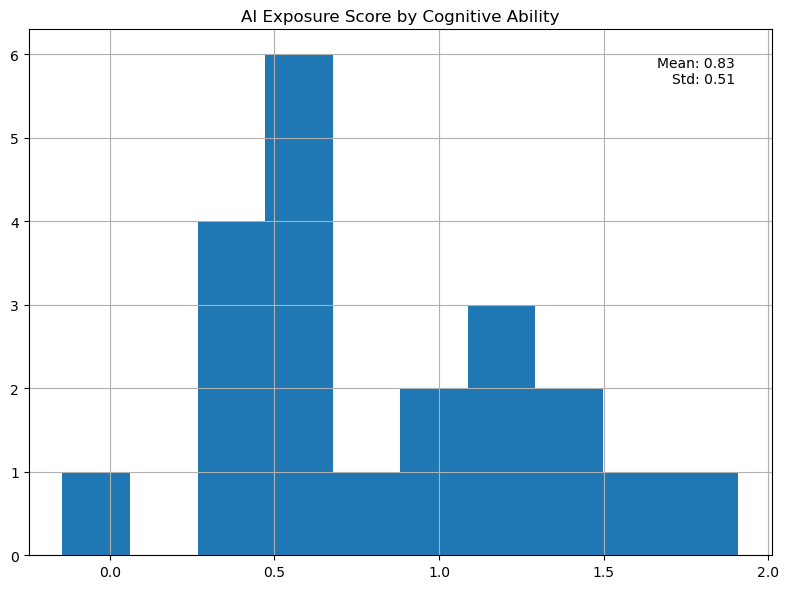

In [119]:
plt.figure(figsize=(8, 6))
cognitive_ability["ai_exposure_score"].hist()
mean = cognitive_ability["ai_exposure_score"].mean()
std = cognitive_ability["ai_exposure_score"].std()
plt.text(0.95, 0.95, f"Mean: {mean:.2f}\nStd: {std:.2f}",
         ha="right", va="top", transform=plt.gca().transAxes)
plt.title("AI Exposure Score by Cognitive Ability")
plt.tight_layout()
os.makedirs("charts", exist_ok=True)
plt.savefig("charts/statistical_analysis_cognitive_ability_exposure.png")
plt.show()

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">3.1.3 occupation_cognitive</h3>
</div>

In [120]:
occupation = occupation_cognitive.select_dtypes(include="number").columns.tolist()

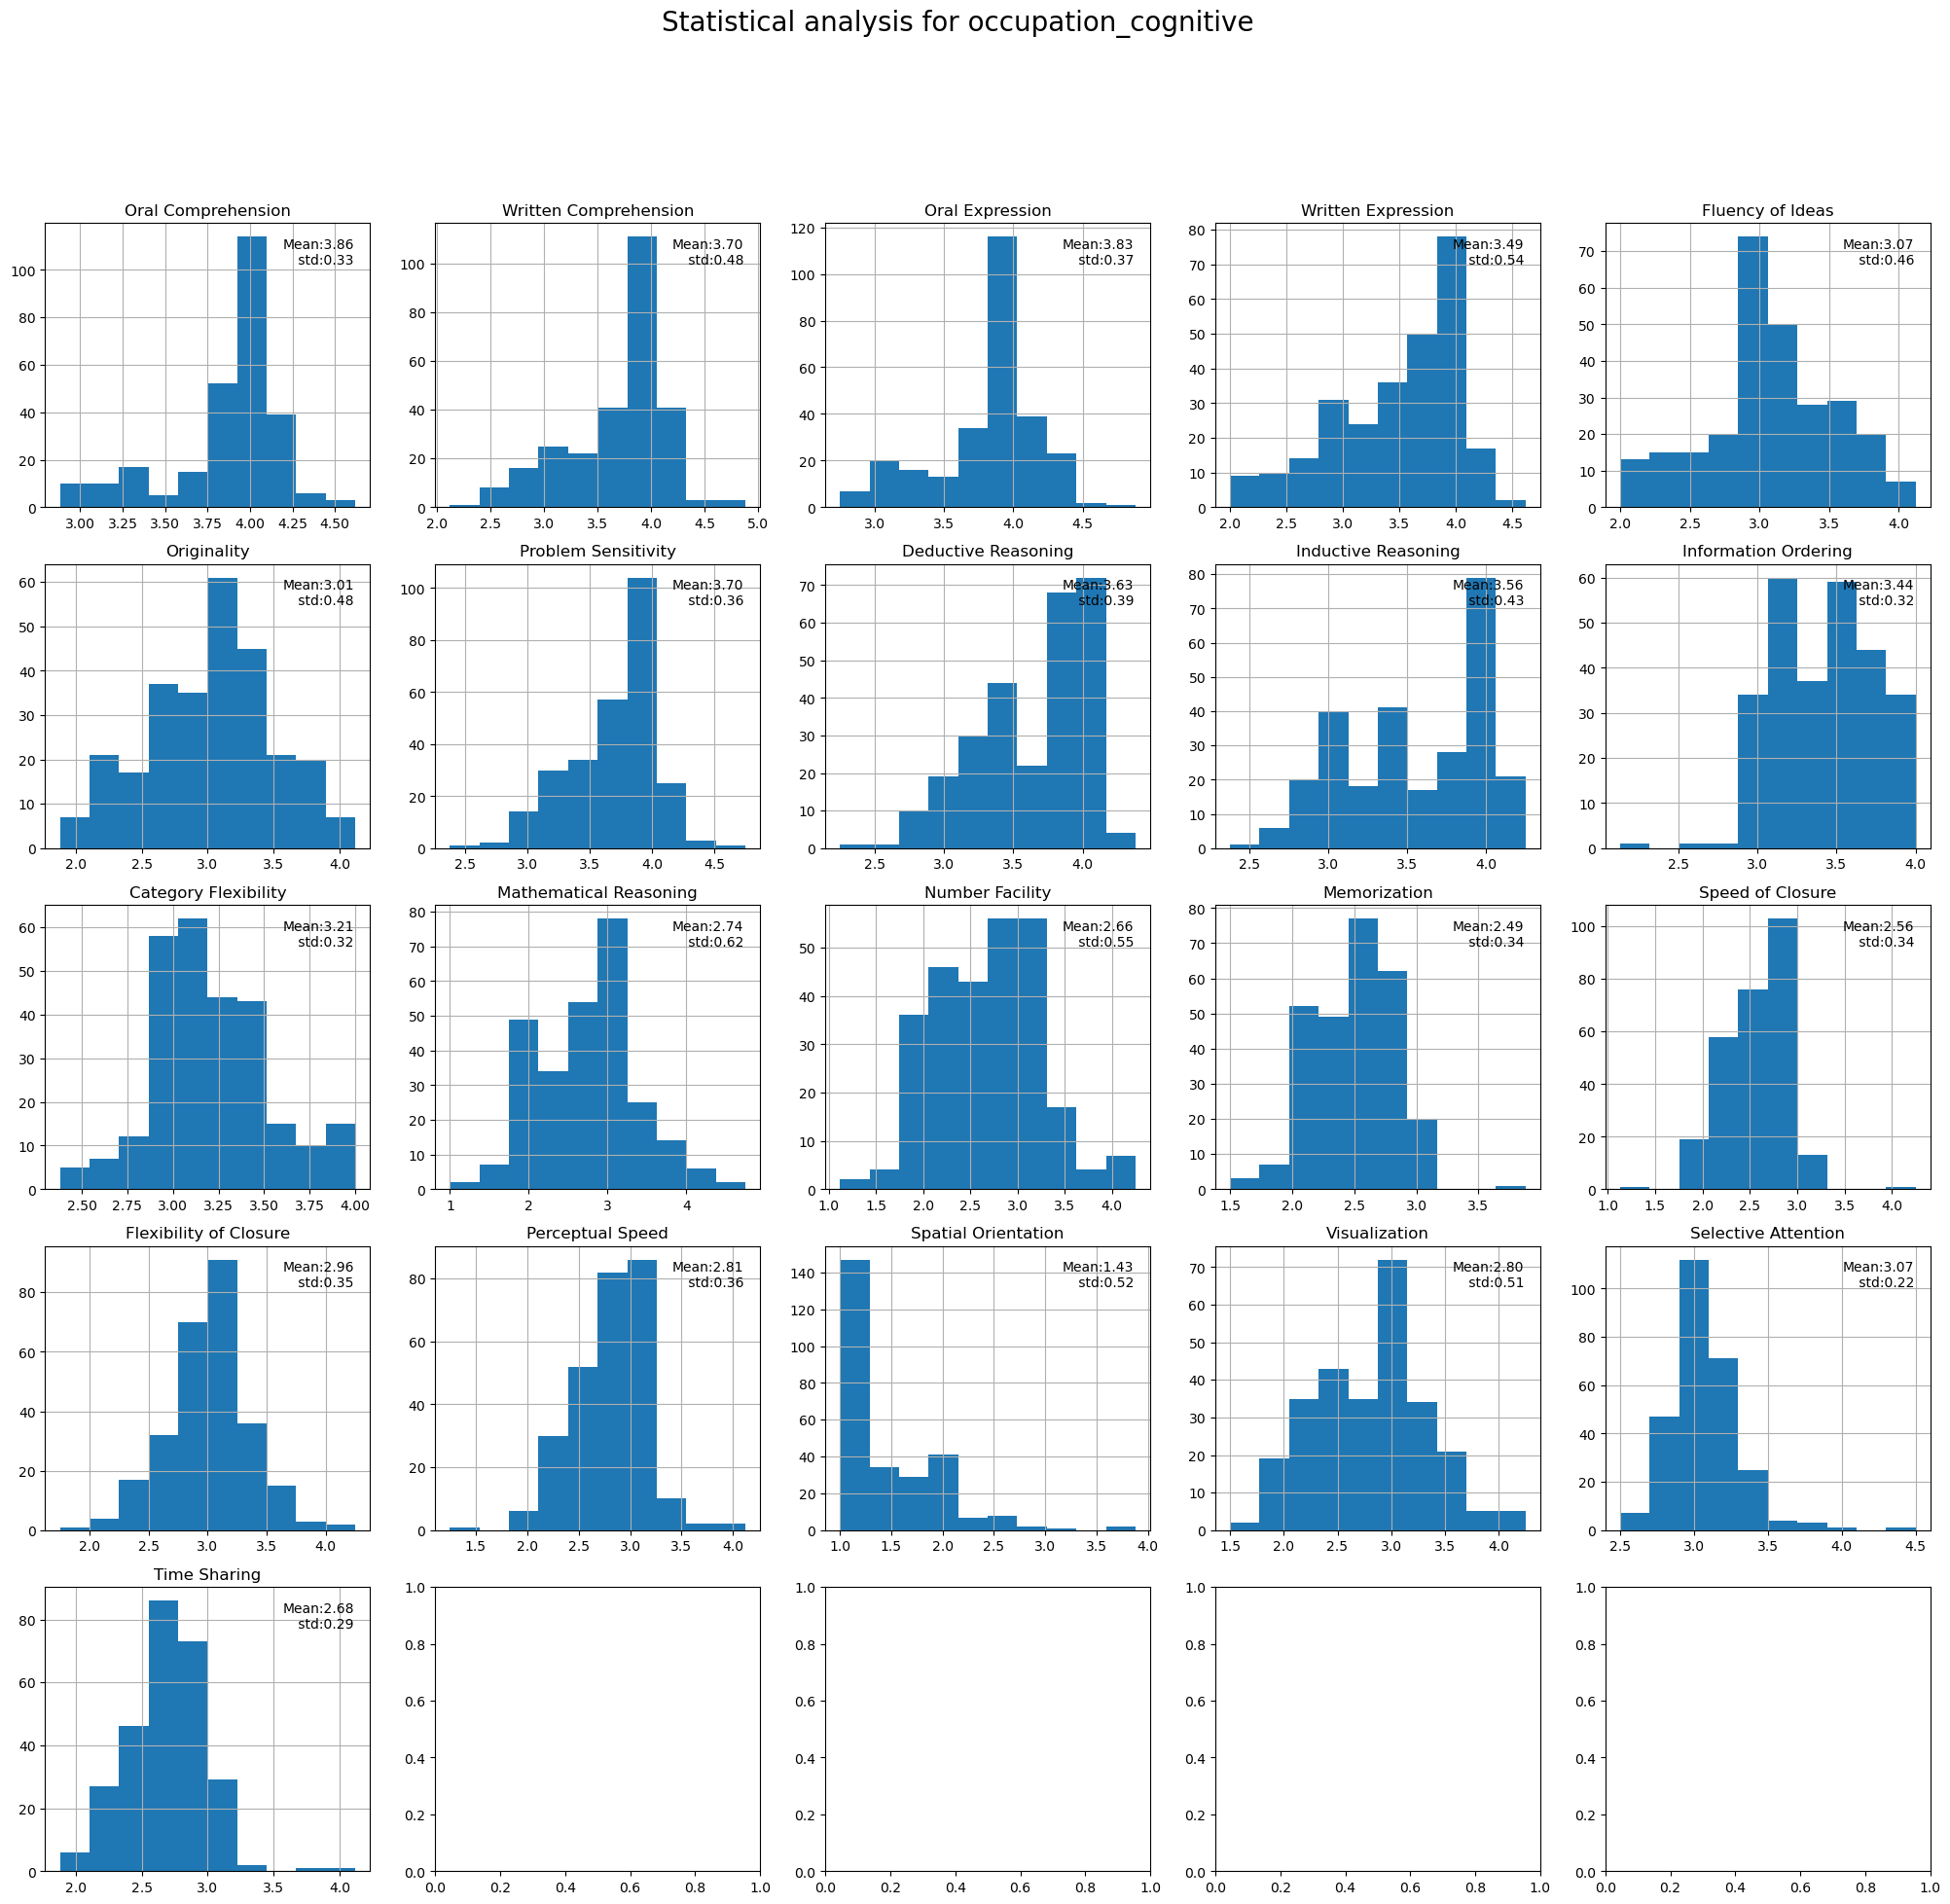

In [125]:
fig,ax = plt.subplots(5,5,figsize=(25,22))
plt.suptitle("Statistical analysis for occupation_cognitive",fontsize=20)
ax = ax.flatten()
for i , name in enumerate(occupation):
    occupation_cognitive[name].hist(ax=ax[i])
    mean = occupation_cognitive[name].mean()
    std = occupation_cognitive[name].std()
    ax[i].text(0.95,0.95,f"Mean:{mean:.2f}\n std:{std:.2f}",
               ha = "right",va="top",transform=ax[i].transAxes)
    ax[i].set_title(name)
plt.tight_layout
plt.savefig("charts/statistical_analysis_occupation_cognitive.png")
plt.show()

**Cognitive Ability → AI Exposure Reference Table** (`cognitive_ability_ai_exposure.csv`)

- Only 21 rows (one per broad cognitive ability), so this distribution is illustrative rather than statistically robust.
- `ai_exposure_score` here (mean 0.83, std 0.51) is on a different scale than the occupation-level `ai_exposure_aioe` — these are ability-level exposure scores, not directly comparable to the occupation-level index without normalization.

**Granular Cognitive Profile** (`occupation_cognitive_profile.csv`)

- Most of the 20 O*NET abilities are roughly bell-shaped and centered between 2.5–4.0, consistent with standard O*NET importance/level scales.
- `Spatial Orientation` is a clear outlier — heavily concentrated near the low end (~1.0–1.5), reflecting that most occupations in this dataset (skewed toward knowledge work) place little demand on spatial reasoning.
- `Mathematical Reasoning` and `Number Facility` show the widest spread (std 0.62 and 0.55 respectively), indicating these abilities vary the most across occupations — likely a strong differentiator between technical/analytical roles and others.

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">3.2 Explanatory Analysis</h3>
</div>

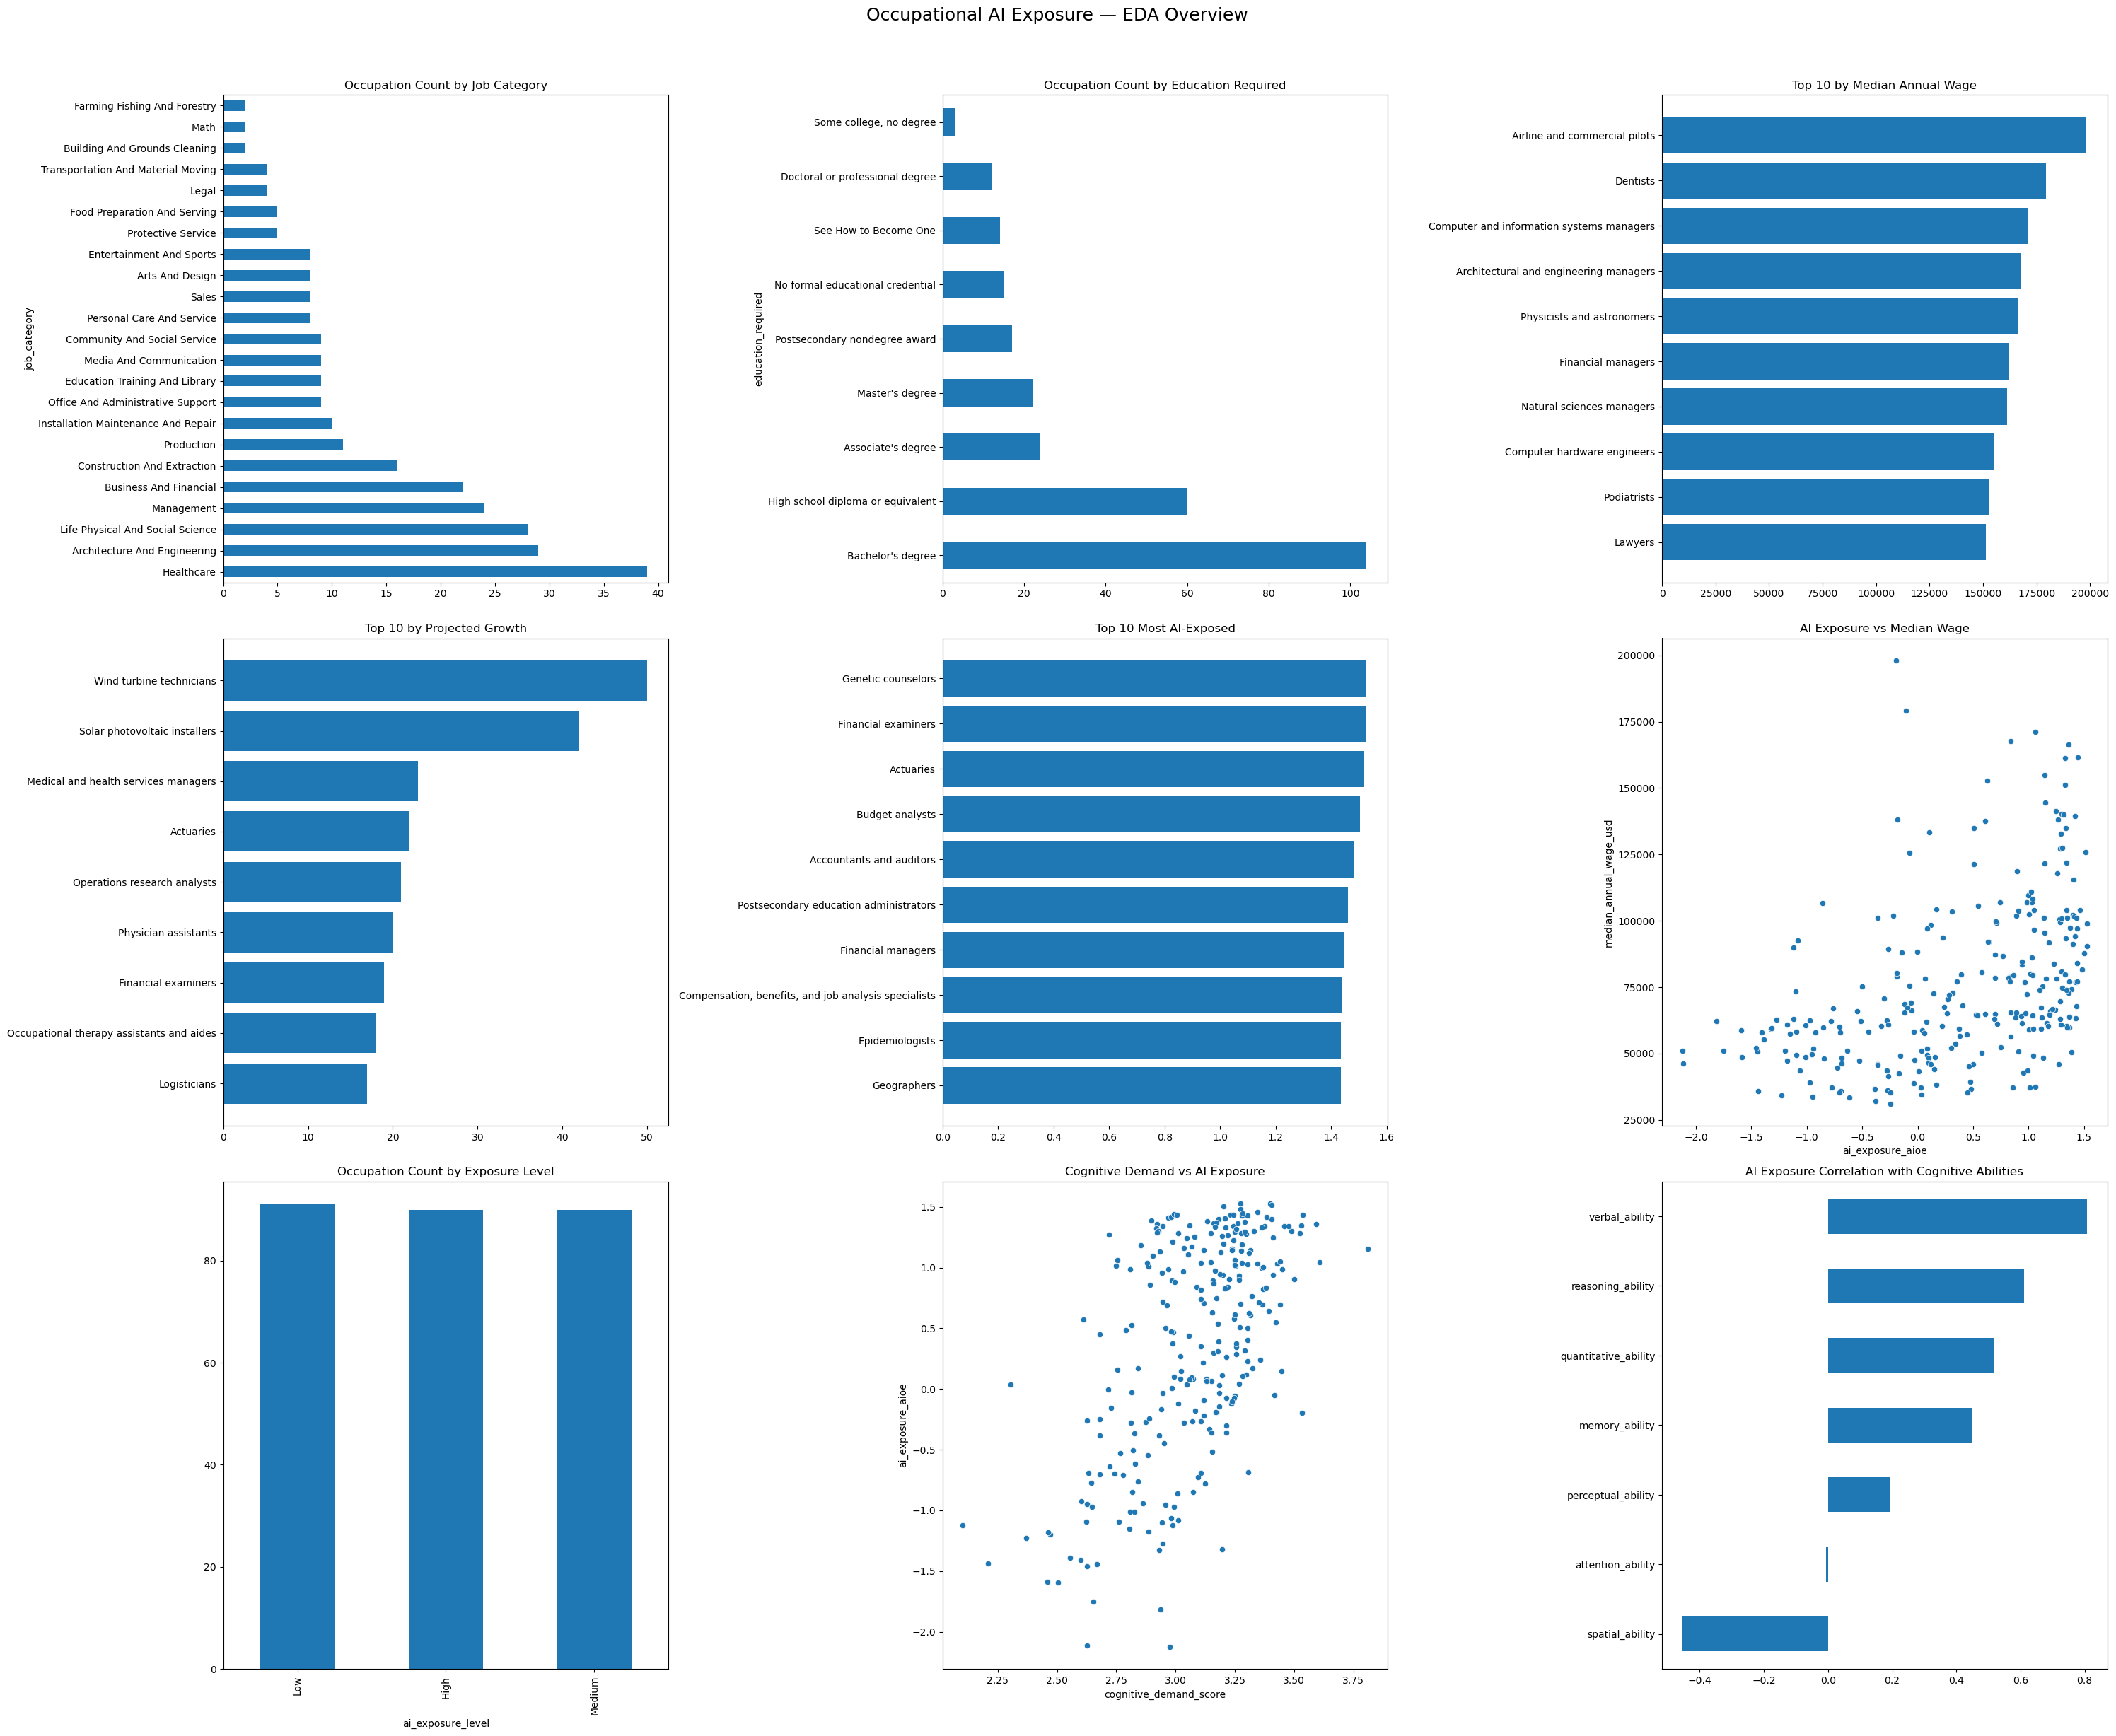

In [133]:
fig, ax = plt.subplots(3, 3, figsize=(30, 25))
ax = ax.flatten()
plt.suptitle("Occupational AI Exposure — EDA Overview", fontsize=18)

# 1. Job category
ai_exposure["job_category"].value_counts().plot(kind="barh", ax=ax[0])
ax[0].set_title("Occupation Count by Job Category")

# 2. Education required
ai_exposure["education_required"].value_counts().plot(kind="barh", ax=ax[1])
ax[1].set_title("Occupation Count by Education Required")

# 3. Top 10 by wage
top_wage = ai_exposure.nlargest(10, "median_annual_wage_usd")
ax[2].barh(top_wage["occupation_title"], top_wage["median_annual_wage_usd"])
ax[2].set_title("Top 10 by Median Annual Wage")
ax[2].invert_yaxis()

# 4. Top 10 by growth
top_growth = ai_exposure.nlargest(9, "projected_growth_pct_2024_2034")
ax[3].barh(top_growth["occupation_title"], top_growth["projected_growth_pct_2024_2034"])
ax[3].set_title("Top 10 by Projected Growth")
ax[3].invert_yaxis()

# 5. Top 10 by AI exposure
top_exposure = ai_exposure.nlargest(10, "ai_exposure_aioe")
ax[4].barh(top_exposure["occupation_title"], top_exposure["ai_exposure_aioe"])
ax[4].set_title("Top 10 Most AI-Exposed")
ax[4].invert_yaxis()

# 6. AI exposure vs wage
sns.scatterplot(data=ai_exposure, x="ai_exposure_aioe", y="median_annual_wage_usd", ax=ax[5])
ax[5].set_title("AI Exposure vs Median Wage")

# 7. AI exposure level
ai_exposure["ai_exposure_level"].value_counts().plot(kind="bar", ax=ax[6])
ax[6].set_title("Occupation Count by Exposure Level")

# 8. Cognitive demand vs AI exposure
sns.scatterplot(data=ai_exposure, x="cognitive_demand_score", y="ai_exposure_aioe", ax=ax[7])
ax[7].set_title("Cognitive Demand vs AI Exposure")

# 9. AI exposure vs cognitive abilities correlation
abilities = ["verbal_ability", "reasoning_ability", "quantitative_ability",
             "memory_ability", "perceptual_ability", "spatial_ability", "attention_ability"]
correlations = ai_exposure[abilities + ["ai_exposure_aioe"]].corr()["ai_exposure_aioe"].drop("ai_exposure_aioe")
correlations.sort_values().plot(kind="barh", ax=ax[8])
ax[8].set_title("AI Exposure Correlation with Cognitive Abilities")

plt.tight_layout(rect=[0, 0, 1, 0.96])
os.makedirs("charts", exist_ok=True)
plt.savefig("charts/eda_overview_grid.png")
plt.show()

## 3.2 EDA Overview — Key Findings

**Dataset composition**
- Healthcare, Architecture & Engineering, and Life/Physical/Social Science are the largest job categories represented — this dataset skews toward technical/knowledge-work occupations rather than a uniform sample of the full labor market. This matters for interpreting results: findings here may not generalize to occupations like transportation, food service, or building/grounds cleaning, which are only lightly represented.
- Bachelor's degree is by far the most common education requirement (~100+ occupations), followed by high school diploma — the dataset is weighted toward higher-education occupations.

**Wage patterns**
- Airline/commercial pilots, dentists, and computer/IS managers top the wage list — a mix of licensed professions and technical management roles, not purely "high-skill tech."
- The AI Exposure vs Median Wage scatter shows a loose positive trend: higher-exposure occupations tend to skew toward higher wages, though the relationship is noisy — plenty of low-exposure occupations still command high wages (likely the pilots/dentists driving the top-right outliers).

**Growth vs exposure — an interesting divergence**
- Fastest-projected-growth occupations (wind turbine technicians, solar installers) are almost entirely different from the most AI-exposed occupations (genetic counselors, financial examiners, actuaries) — growth and AI exposure appear to be largely independent dimensions, not the same story. Fast-growing jobs here lean toward renewable-energy/technical trades, not the knowledge-work roles most exposed to AI.
- The most AI-exposed occupations are heavily finance/analytics-flavored (financial examiners, actuaries, budget analysts, accountants) — directly relevant to the fintech framing of this project.

**Exposure level distribution**
- Low, Medium, and High exposure categories are almost perfectly balanced (~90 occupations each) — suggesting `ai_exposure_level` was likely constructed as tertiles (even thirds) of the exposure score, rather than reflecting a natural break in the data. Worth confirming this in the notebook rather than treating the three categories as inherently meaningful cutoffs.

**Cognitive demand vs AI exposure**
- A clear positive relationship: occupations with higher cognitive demand scores show consistently higher AI exposure. This is the most visually convincing relationship in the grid — cognitive demand looks like a strong candidate predictor.

**Which cognitive abilities matter most**
- `verbal_ability` shows the strongest positive correlation with AI exposure (~0.8), followed by `reasoning_ability` and `quantitative_ability` — confirming the dataset's own stated finding: AI exposure concentrates in occupations leaning on language and analytical reasoning.
- `spatial_ability` is the only clearly negative correlate (~-0.4) — occupations requiring strong spatial reasoning tend to be the least AI-exposed, consistent with the earlier finding that physical/spatial trades (roofers, electricians) sit at the low end of exposure.
- `attention_ability` shows essentially zero correlation — attention/vigilance demands don't meaningfully predict AI exposure either way.


**Implication for modeling**: verbal, reasoning, and quantitative ability plus cognitive demand score look like the strongest candidate features for predicting AI exposure — spatial ability as a negative predictor, and attention ability likely contributes little.

In [ ]:
<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">3. Explanatory Data Analysis (EDA)</h2>
</div>